In [89]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt

In [90]:
# Loading the training and testing dataset

def load_dataset() :
    train = np.load('t.npz')
    train_x = train['train_x']
    train_y = train['train_y']

    test = np.load('t1.npz')
    test_x = test['test_x']
    test_y = test['test_y']

    return train_x, train_y, test_x, test_y

train_X, train_Y, test_X, test_Y = load_dataset()

In [91]:
# Function to initilast_lpise para W and b

def initilast_lpise_parameters(dims) :
    np.random.seed(5)
    para = {}
    L = len(dims)

    for l in range(1, L) :
        para['W' + str(l)] = np.random.randn(dims[l], dims[l - 1]) / np.sqrt(dims[l - 1])
        para['b' + str(l)] = np.zeros((dims[l], 1))
    
    return para

In [92]:
# Defining the activation functions

def sigmoid(V) :
    A = 1 / (1 + np.exp(-V))
    assert A.shape == V.shape
    return A

def relu(V) :
    A = np.maximum(0, V)
    assert A.shape == V.shape
    return A

In [93]:
# Forward propagation

def forward_propagation(X, para) :
    W1 = para['W1']
    b1 = para['b1']
    W2 = para['W2']
    b2 = para['b2']
    W3 = para['W3']
    b3 = para['b3']
    W4 = para['W4']
    b4 = para['b4']

    V1 = np.dot(W1, X) + b1
    A1 = relu(V1)

    V2 = np.dot(W2, A1) + b2
    A2 = relu(V2)

    V3 = np.dot(W3, A2) + b3
    A3 = relu(V3)

    V4 = np.dot(W4, A3) + b4
    A4 = sigmoid(V4)

    cache = (V1, A1, W1, b1, V2, A2, W2, b2, V3, A3, W3, b3, A4, W4, b4)

    return A4, cache

In [94]:
# find the cost or loss in the function

def find_cost(last_lp, Y) :
    m = Y.shape[1]
    epsilon = 1e-9

    probs = np.multiply(-np.log(np.clip(last_lp, epsilon, 1 - epsilon)), Y) + np.multiply(-np.log(np.clip(1 - last_lp, epsilon, 1-epsilon)), 1 - Y)
    cost = 1./m * np.nansum(probs)

    return cost

In [95]:
# Backward propagation

def backward_propagation(X, Y, cache) :
    m = X.shape[1]
    (V1, A1, W1, b1, V2, A2, W2, b2, V3, A3, W3, b3, A4, W4, b4) = cache

    dV4 = A4 - Y
    dW4 = 1./m * np.dot(dV4, A3.T)
    db4 = 1./m * np.sum(dV4, axis=1, keepdims = True)

    dA3 = np.dot(W4.T, dV4)
    dV3 = np.multiply(dA3, np.int64(A3 > 0))
    dW3 = 1./m * np.dot(dV3, A2.T)
    db3 = 1./m * np.sum(dV3, axis=1, keepdims = True)

    dA2 = np.dot(W3.T, dV3)
    dV2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = 1./m * np.dot(dV2, A1.T)
    db2 = 1./m * np.sum(dV2, axis=1, keepdims = True)

    dA1 = np.dot(W2.T, dV2)
    dV1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = 1./m * np.dot(dV1, X.T)
    db1 = 1./m * np.sum(dV1, axis=1, keepdims = True)

    grads = {"dV4": dV4, "dW4": dW4, "db4": db4,
             "dA3": dA3, "dV3": dV3, "dW3": dW3, "db3": db3,
             "dA2": dA2, "dV2": dV2, "dW2": dW2, "db2": db2,
             "dA1": dA1, "dV1": dV1, "dW1": dW1, "db1": db1}
    
    return grads

In [96]:
def update_para(para, gradient, learning_rate = 0.1) :
    L = len(para) // 2

    for l in range(L):
        para["W" + str(l+1)] = para["W" + str(l+1)] - learning_rate * gradient["dW" + str(l+1)]
        para["b" + str(l+1)] = para["b" + str(l+1)] - learning_rate * gradient["db" + str(l+1)]
        
    return para

In [97]:
def predict(X, para) :
    m = X.shape[1]
    Y_pred = np.zeros((1, m))

    A, caches = forward_propagation(X, para)

    for i in range(0, A.shape[1]) :
        if A[0, i] > 0.5 :
            Y_pred[0, i] = 1
        else :
            Y_pred[0, i] = 0
    
    return Y_pred

In [98]:
# our model of face detection

def model(X, Y, iterations = 800, learning_rate = 0.1) :
    costs = []
    dims = [X.shape[0], 400, 30, 5, 1]

    para = initilast_lpise_parameters(dims)

    for i in range(0, iterations + 1) :
        last_lp, caches = forward_propagation(X, para)
        cost = find_cost(last_lp, Y)
        grads = backward_propagation(last_lp, Y, caches)
        para = update_para(para, grads, learning_rate)

        if i % 100 == 0 :
            costs.append(cost)
            print("Cost after iteration %i: %f" %(i, cost))

    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (x100)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()
    
    return para

Cost after iteration 0: 0.669794
Cost after iteration 100: 0.227348
Cost after iteration 200: 0.211792
Cost after iteration 300: 0.207056
Cost after iteration 400: 0.198771
Cost after iteration 500: 0.190011
Cost after iteration 600: 0.182775
Cost after iteration 700: 0.176187
Cost after iteration 800: 0.169132


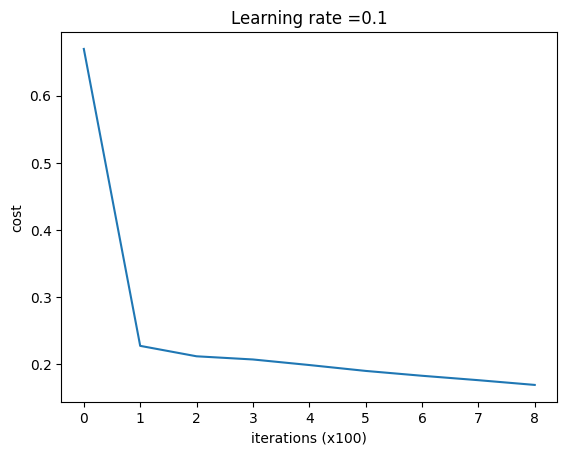

In [99]:
# retrieve the trained para from the model

para = model(train_X, train_Y)

In [100]:
# use the trained para for prediction
# on the training set and the test set

train_Y_pred = predict(train_X, para)
print("train accuracy: {} %".format(100 - np.mean(np.abs(train_Y_pred - train_Y)) * 100))

test_Y_pred = predict(test_X, para)
print("test accuracy: {} %".format(100 - np.mean(np.abs(test_Y_pred - test_Y)) * 100))

train accuracy: 96.34703196347031 %
test accuracy: 86.39455782312925 %
